In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [21]:
# 1. Load Data
df = pd.read_csv('card_transdata.csv')

In [22]:
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [23]:
df.sample(5)

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
852663,22.423876,2.574376,1.768730,1.0,0.0,0.0,1.0,0.0
649504,139.190601,1.293707,1.525505,1.0,1.0,0.0,1.0,0.0
603420,2.267394,0.018730,6.817842,1.0,0.0,1.0,1.0,0.0
712709,3.832151,1.264342,1.718137,1.0,0.0,0.0,1.0,0.0
154874,1.019404,0.377054,2.369977,0.0,0.0,0.0,0.0,0.0


In [24]:
# 2. Senior-Level Feature: Checking for Imbalance
# (In fraud datasets, 0 is usually 90% of data. We must acknowledge this!)
print(df['fraud'].value_counts(normalize=True))


fraud
0.0    0.912597
1.0    0.087403
Name: proportion, dtype: float64


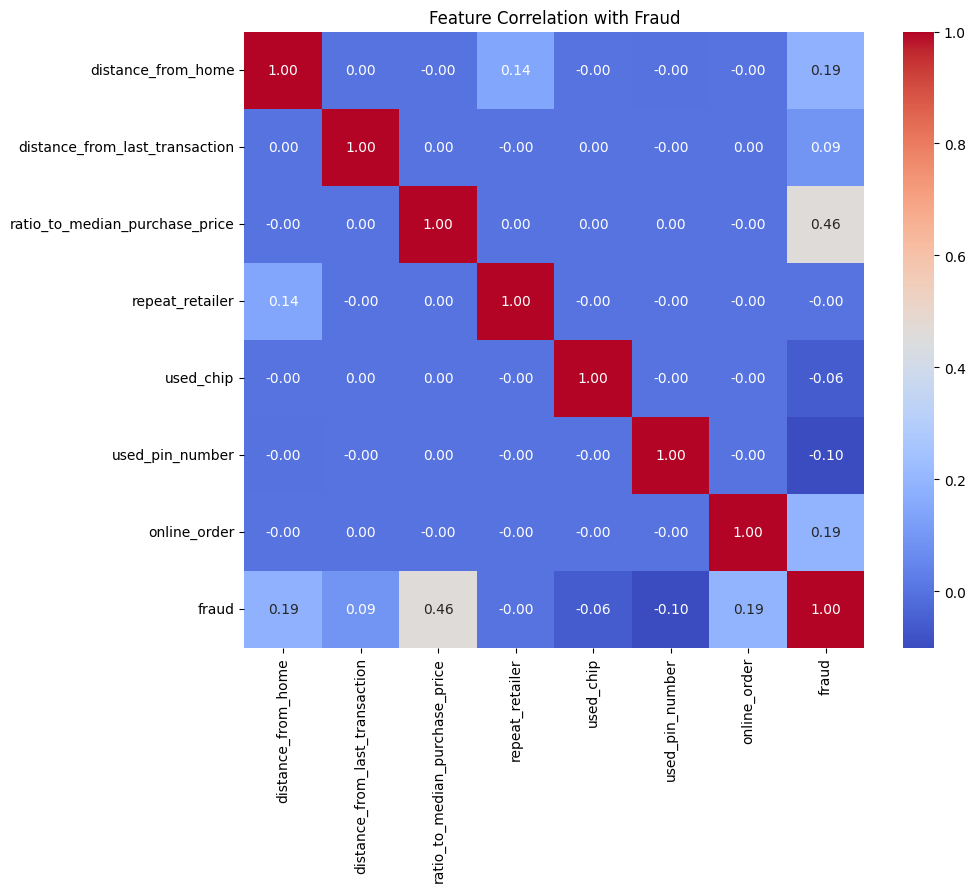

In [25]:
# EDA Step 1: Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation with Fraud')
plt.show()

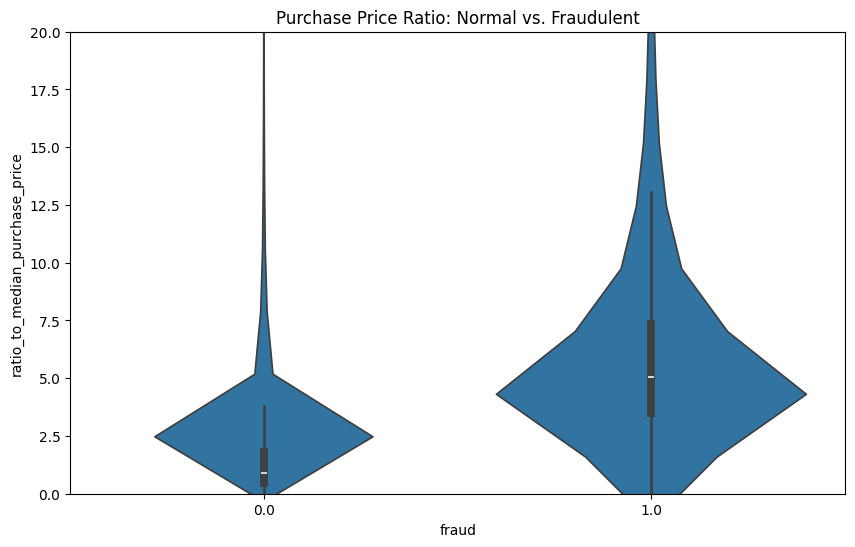

In [26]:
# EDA Step 2: Distribution of Purchase Price Ratio
plt.figure(figsize=(10, 6))
sns.violinplot(x='fraud', y='ratio_to_median_purchase_price', data=df)
plt.ylim(0, 20)
plt.title('Purchase Price Ratio: Normal vs. Fraudulent')
plt.show()

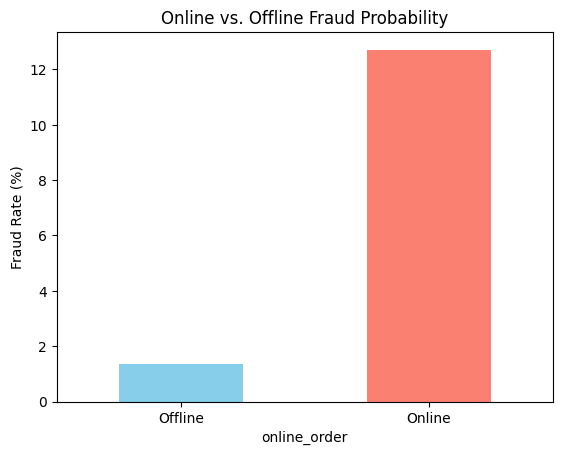

In [27]:
# EDA Step 3: Fraud Rate by Order Type
pivot_table = df.groupby('online_order')['fraud'].mean() * 100
pivot_table.plot(kind='bar', color=['skyblue', 'salmon'])
plt.ylabel('Fraud Rate (%)')
plt.title('Online vs. Offline Fraud Probability')
plt.xticks([0, 1], ['Offline', 'Online'], rotation=0)
plt.show()

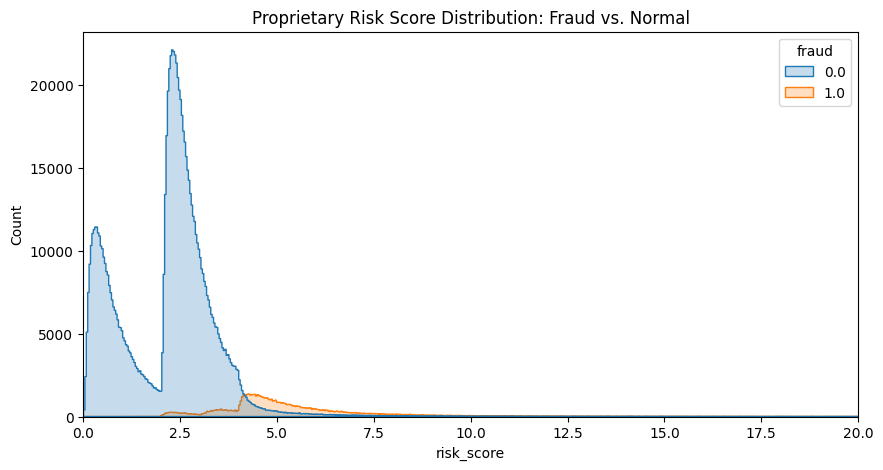

In [28]:
# --- STEP 2.5: FEATURE ENGINEERING (The 'Consulting' Touch) ---
# Create a weighted risk score based on high-risk factors
df['risk_score'] = (
    (df['ratio_to_median_purchase_price'] * 0.5) + 
    (df['online_order'] * 2.0) + 
    (df['distance_from_home'] * 0.01)
)

# Visualize the Risk Score Distribution
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='risk_score', hue='fraud', element='step', common_norm=False)
plt.title('Proprietary Risk Score Distribution: Fraud vs. Normal')
plt.xlim(0, 20) # Focusing on the most relevant range
plt.show()

In [29]:
# --- STEP 2.6: SEGMENTED RISK PROFILING ---
# Looking at the 99th percentile of 'ratio_to_median'
high_value_threshold = df['ratio_to_median_purchase_price'].quantile(0.99)
high_value_segment = df[df['ratio_to_median_purchase_price'] > high_value_threshold]

print(f"High-Value Segment (> {high_value_threshold:.2f}x Median Price):")
print(f"Fraud Rate in this segment: {high_value_segment['fraud'].mean()*100:.2f}%")
print(f"General Fraud Rate: {df['fraud'].mean()*100:.2f}%")

High-Value Segment (> 12.79x Median Price):
Fraud Rate in this segment: 63.59%
General Fraud Rate: 8.74%


In [30]:
# --- STEP 6.1: DECISION PATH INSIGHT ---
# Let's look at why the model flags a specific transaction
sample_fraud = X_test[y_test == 1].iloc[0]
print("\nDeep Dive: Why was this specific transaction flagged as FRAUD?")
for i, feature in enumerate(X.columns):
    print(f"{feature}: {sample_fraud[feature]} (Importance Weight: {model.feature_importances_[i]:.4f})")


Deep Dive: Why was this specific transaction flagged as FRAUD?
distance_from_home: 131.56029999005267 (Importance Weight: 0.1949)
distance_from_last_transaction: 1.8798586040689265 (Importance Weight: 0.0755)
ratio_to_median_purchase_price: 0.5761089559751786 (Importance Weight: 0.5472)
repeat_retailer: 1.0 (Importance Weight: 0.0078)
used_chip: 0.0 (Importance Weight: 0.0258)
used_pin_number: 0.0 (Importance Weight: 0.0336)
online_order: 1.0 (Importance Weight: 0.1152)


In [31]:
# 3. Split Data
X = df.drop('fraud', axis=1)
y = df['fraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [32]:
# 4. Train Model (Random Forest is great for "Explainable AI")
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

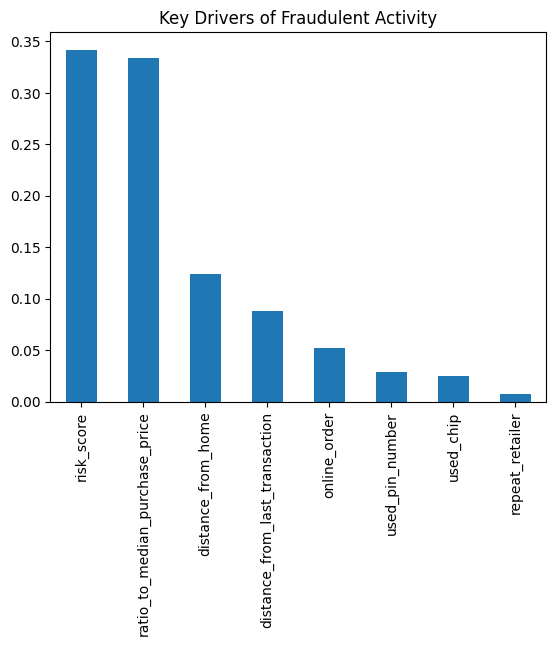

In [33]:
# 5. Get "Consulting Insights" (Feature Importance)
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='bar', title='Key Drivers of Fraudulent Activity')
plt.show()


In [34]:
# 6. Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182557
         1.0       1.00      1.00      1.00     17443

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000

